In [1]:
#%pip install pandas numpy matplotlib scikit-learn statsmodels

# Demand Forecasting - BICUP 2006 Data

We have 21 days of demand data (March 1-21, 2005) recorded every 15 minutes from 6:30 AM to 10:00 PM.

**Goal:** Forecast demand for the last week (Mar 15-21) using the first two weeks (Mar 1-14) as training data.

In [2]:
import pandas as pd

raw_data = pd.read_csv('bicup2006_Data.csv')
raw_data.head()

,DATE,TIME,DEMAND
0,1-Mar-05,6:30,1
1,1-Mar-05,6:45,2
2,1-Mar-05,7:00,4
3,1-Mar-05,7:15,0
4,1-Mar-05,7:30,10


## Data Prep

Create a proper datetime index from the DATE and TIME columns.

In [3]:
data = raw_data.copy()
data['datetime'] = pd.to_datetime(data['DATE'] + ' ' + data['TIME'])
data.set_index('datetime', inplace=True)
data.drop(columns=['DATE', 'TIME'], inplace=True)
data.sort_index(inplace=True)
data.head()

C:\Users\LEGION\AppData\Local\Temp\ipykernel_16036\611145152.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['datetime'] = pd.to_datetime(data['DATE'] + ' ' + data['TIME'])


,DEMAND
datetime,
2005-03-01 06:30:00,1
2005-03-01 06:45:00,2
2005-03-01 07:00:00,4
2005-03-01 07:15:00,0
2005-03-01 07:30:00,10


In [4]:
# Check for missing values
print("Missing values:", data.isnull().sum().to_dict())

Missing values: {'DEMAND': 0}


Outliers (Z > 3): 16


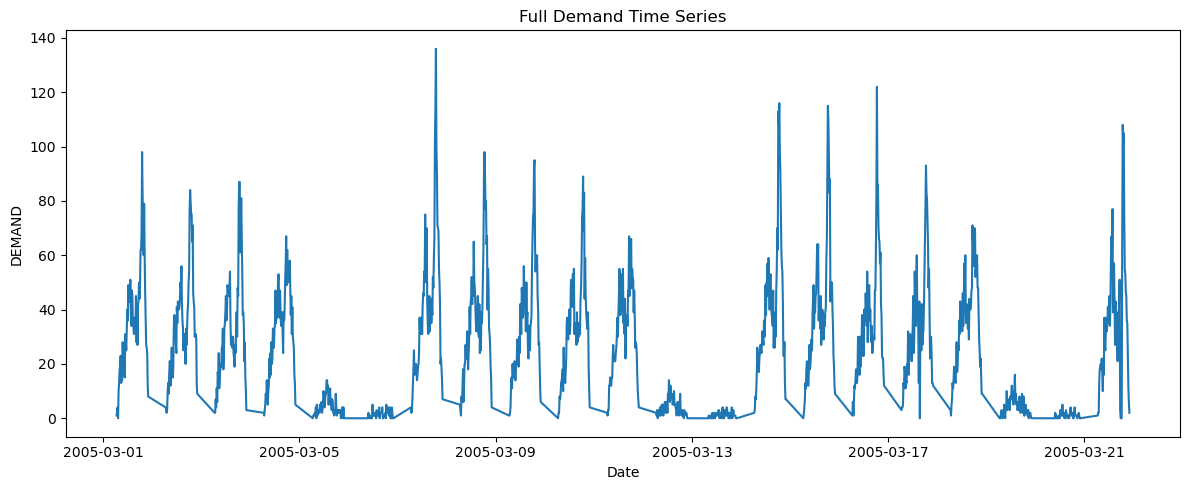

In [5]:
# Check for outliers using Z-score
from scipy import stats
import matplotlib.pyplot as plt

z_scores = stats.zscore(data['DEMAND'])
outliers = (abs(z_scores) > 3).sum()
print(f"Outliers (Z > 3): {outliers}")

# Plot the time series
plt.figure(figsize=(12, 5))
plt.plot(data.index, data['DEMAND'])
plt.xlabel('Date')
plt.ylabel('DEMAND')
plt.title('Full Demand Time Series')
plt.tight_layout()
plt.show()

## Exploratory Analysis

Let's look at patterns: daily rhythm, distribution, and day-of-week differences.

C:\Users\LEGION\AppData\Local\Temp\ipykernel_16036\61763561.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(daily_data, labels=day_names, patch_artist=True)


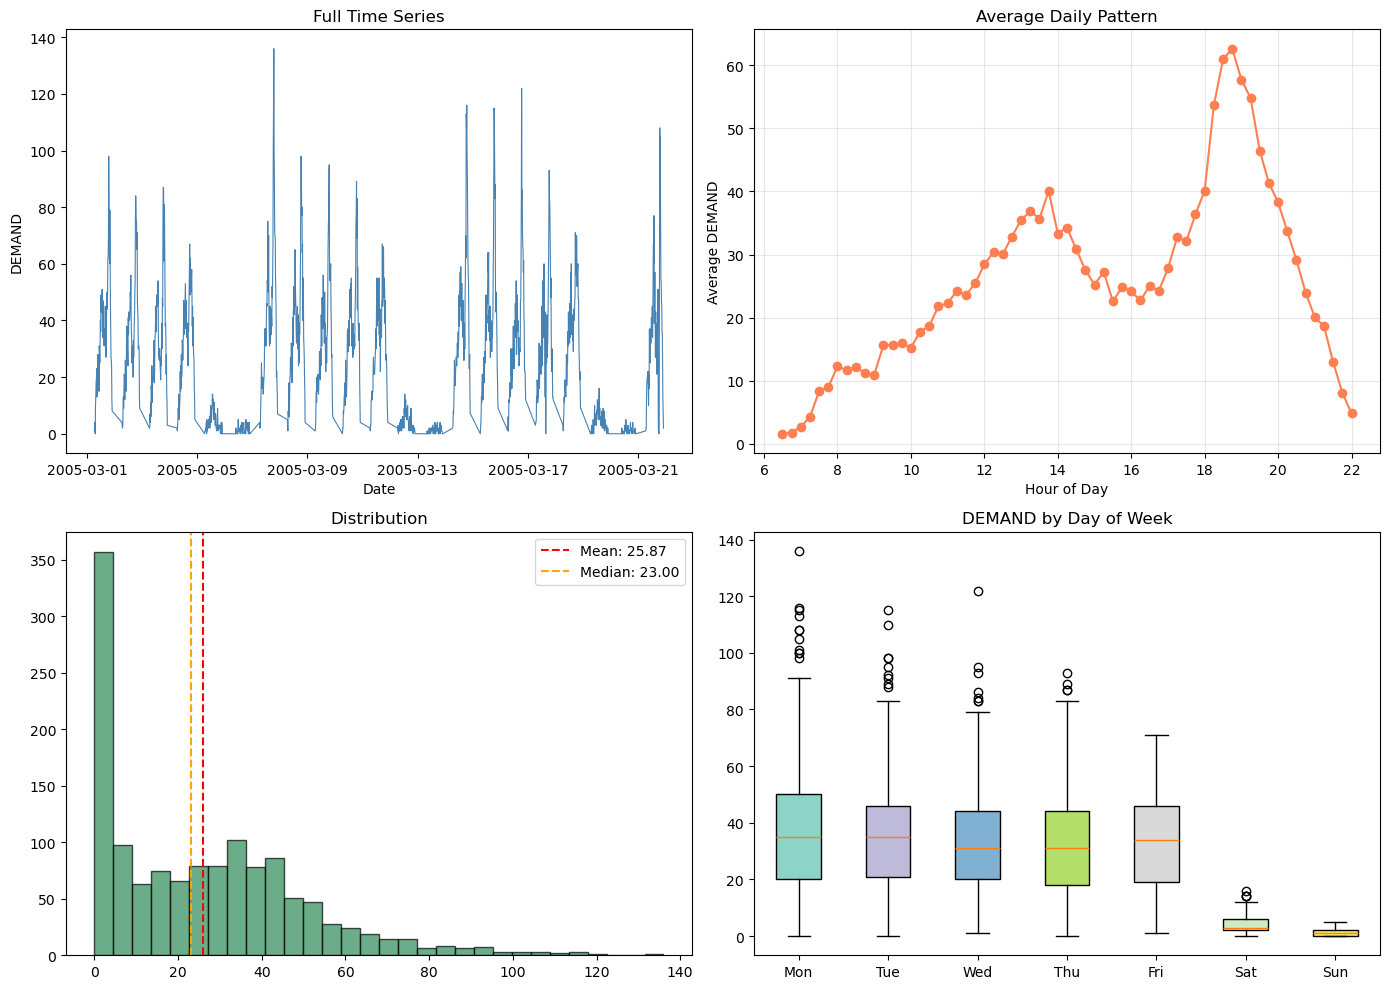

In [6]:
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time series
axes[0, 0].plot(data.index, data['DEMAND'], color='steelblue', linewidth=0.8)
axes[0, 0].set_title('Full Time Series')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('DEMAND')

# Daily pattern
data['hour'] = data.index.hour + data.index.minute / 60
hourly_avg = data.groupby('hour')['DEMAND'].mean()
axes[0, 1].plot(hourly_avg.index, hourly_avg.values, marker='o', color='coral')
axes[0, 1].set_title('Average Daily Pattern')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Average DEMAND')
axes[0, 1].grid(True, alpha=0.3)

# Distribution
axes[1, 0].hist(data['DEMAND'], bins=30, color='seagreen', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(data['DEMAND'].mean(), color='red', linestyle='--', label=f'Mean: {data["DEMAND"].mean():.2f}')
axes[1, 0].axvline(data['DEMAND'].median(), color='orange', linestyle='--', label=f'Median: {data["DEMAND"].median():.2f}')
axes[1, 0].set_title('Distribution')
axes[1, 0].legend()

# Weekly pattern - notice weekends are much lower
data['day_of_week'] = data.index.dayofweek
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_data = [data[data['day_of_week'] == i]['DEMAND'].values for i in range(7)]
bp = axes[1, 1].boxplot(daily_data, labels=day_names, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.Set3(np.linspace(0, 1, 7))):
    patch.set_facecolor(color)
axes[1, 1].set_title('DEMAND by Day of Week')

plt.tight_layout()
plt.show()

data.drop(columns=['hour', 'day_of_week'], inplace=True)

## STL Decomposition

Break down the signal into trend, seasonal (daily pattern), and residual components.

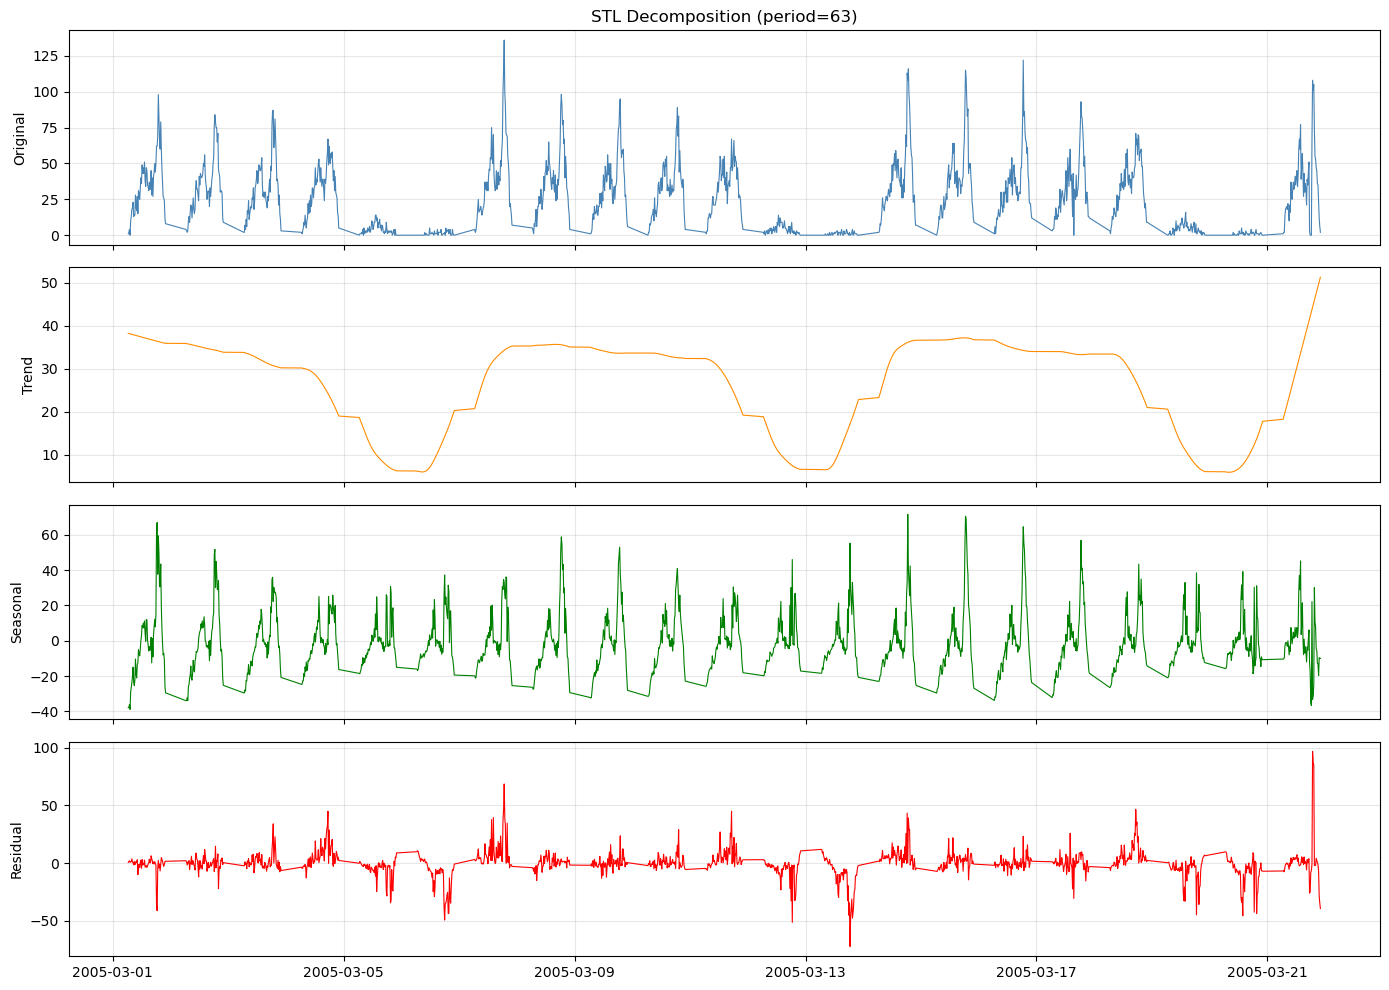

Variance explained - Trend: 21.7%, Seasonal: 50.5%, Residual: 25.5%


In [7]:
# STL Decomposition (63 obs/day = 15-min intervals)
from statsmodels.tsa.seasonal import STL

stl = STL(data['DEMAND'], period=63, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
components = [('Original', data['DEMAND'], 'steelblue'),
              ('Trend', result.trend, 'darkorange'),
              ('Seasonal', result.seasonal, 'green'),
              ('Residual', result.resid, 'red')]

for ax, (name, comp, color) in zip(axes, components):
    ax.plot(data.index, comp, color=color, linewidth=0.8)
    ax.set_ylabel(name)
    ax.grid(True, alpha=0.3)

axes[0].set_title('STL Decomposition (period=63)')
plt.tight_layout()
plt.show()

# How much of the variance each component explains
total_var = data['DEMAND'].var()
print(f"Variance explained - Trend: {result.trend.var()/total_var*100:.1f}%, "
      f"Seasonal: {result.seasonal.var()/total_var*100:.1f}%, "
      f"Residual: {result.resid.var()/total_var*100:.1f}%")

In [8]:
# Quick data structure check
obs_per_day = data.groupby(data.index.date).size()
print(f"Date range: {data.index.min().date()} to {data.index.max().date()}")
print(f"Total obs: {len(data)}, Days: {len(obs_per_day)}, Obs/day: {obs_per_day.median():.0f}")

Date range: 2005-03-01 to 2005-03-21
Total obs: 1323, Days: 21, Obs/day: 63


## ACF/PACF Analysis

Check autocorrelation patterns. Spikes at lag 63 = daily seasonality (63 readings/day).

Trend strength: 0.6548 (Strong)
Seasonal strength: 0.6521 (Strong)


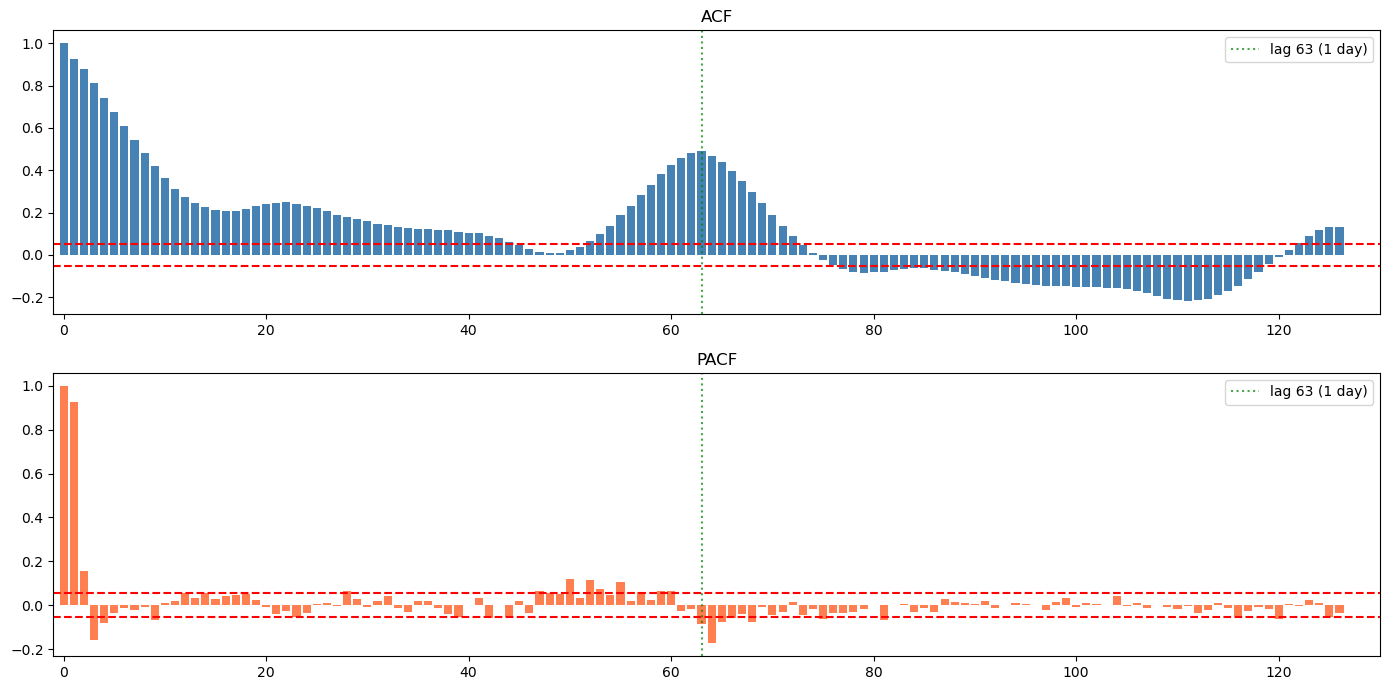

In [9]:
# Time series features
from tsfeatures import stl_features, acf_features
from statsmodels.tsa.stattools import acf, pacf

ts_data = data['DEMAND'].values
stl_feats = stl_features(ts_data, freq=63)
acf_feats = acf_features(ts_data)

trend_strength = stl_feats.get('trend', 0)
seasonal_strength = stl_feats.get('seasonal_strength', 0)

print(f"Trend strength: {trend_strength:.4f} ({'Strong' if trend_strength > 0.6 else 'Moderate' if trend_strength > 0.3 else 'Weak'})")
print(f"Seasonal strength: {seasonal_strength:.4f} ({'Strong' if seasonal_strength > 0.6 else 'Moderate' if seasonal_strength > 0.3 else 'Weak'})")

# ACF/PACF plots
acf_values = acf(data['DEMAND'], nlags=126, fft=True)
pacf_values = pacf(data['DEMAND'], nlags=126)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax, vals, title, color in [(axes[0], acf_values, 'ACF', 'steelblue'), 
                                (axes[1], pacf_values, 'PACF', 'coral')]:
    ax.bar(range(len(vals)), vals, color=color, width=0.8)
    ax.axhline(y=1.96/np.sqrt(len(data)), color='red', linestyle='--')
    ax.axhline(y=-1.96/np.sqrt(len(data)), color='red', linestyle='--')
    ax.axvline(x=63, color='green', linestyle=':', alpha=0.7, label='lag 63 (1 day)')
    ax.set_title(title)
    ax.set_xlim(-1, 130)
    ax.legend()
plt.tight_layout()
plt.show()

---
## Forecasting Model

**Approach:** Day-Specific Pattern Model - each day of the week has its own demand pattern.

 The boxplot showed clear weekday/weekend differences. Instead of treating all days the same, we learn separate patterns for Monday, Tuesday, etc.

In [10]:
# Train-test split: 2 weeks training, 1 week testing
split_date = '2005-03-15'
train_data = data[data.index < split_date].copy()
test_data = data[data.index >= split_date].copy()

print(f"Training: {train_data.index.min().date()} to {train_data.index.max().date()} ({len(train_data)} samples)")
print(f"Test: {test_data.index.min().date()} to {test_data.index.max().date()} ({len(test_data)} samples)")

Training: 2005-03-01 to 2005-03-14 (882 samples)
Test: 2005-03-15 to 2005-03-21 (441 samples)


In [11]:
# Helper functions for metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

def calculate_metrics(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

In [12]:
# Build day-specific patterns from training data
# For each day of the week (Mon=0, Sun=6), learn the typical demand at each 15-min slot

import warnings
warnings.filterwarnings('ignore')

train_data['time_slot'] = (train_data.index.hour * 4 + train_data.index.minute // 15).astype(int)
train_data['day_of_week'] = train_data.index.dayofweek

day_patterns = {}
for day in range(7):
    day_data = train_data[train_data['day_of_week'] == day]
    day_patterns[day] = day_data.groupby('time_slot')['DEMAND'].mean()

# Fill any missing slots with day average
for day in range(7):
    day_mean = day_patterns[day].mean() if len(day_patterns[day]) > 0 else 0
    for slot in range(63):
        if slot not in day_patterns[day].index:
            day_patterns[day][slot] = day_mean

# Show what we learned
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
print("Average demand by day:")
for day, name in enumerate(day_names):
    print(f"  {name}: {day_patterns[day].mean():.2f}")

train_data.drop(columns=['time_slot', 'day_of_week'], inplace=True)

Average demand by day:
  Mon: 40.33
  Tue: 35.91
  Wed: 34.22
  Thu: 33.21
  Fri: 31.89
  Sat: 4.11
  Sun: 1.12


In [13]:
# Generate predictions
def predict(timestamp, day_patterns):
    day = timestamp.dayofweek
    slot = timestamp.hour * 4 + timestamp.minute // 15
    return day_patterns[day].get(slot, day_patterns[day].mean())

# Fitted values on training data
fitted_values_train = pd.Series([predict(idx, day_patterns) for idx in train_data.index], index=train_data.index)

# Forecast for test period
forecast_series = pd.Series([predict(idx, day_patterns) for idx in test_data.index], index=test_data.index)

print(f"Training predictions: {len(fitted_values_train)}")
print(f"Test predictions: {len(forecast_series)}")

Training predictions: 882
Test predictions: 441


In [14]:
# Calculate metrics
train_metrics = calculate_metrics(train_data['DEMAND'].values, fitted_values_train.values)
test_metrics = calculate_metrics(test_data['DEMAND'].values, forecast_series.values)

train_residuals = train_data['DEMAND'].values - fitted_values_train.values
test_residuals = test_data['DEMAND'].values - forecast_series.values

# MAPE filtered (excluding near-zero values which inflate MAPE)
mask_train = train_data['DEMAND'].values > 1
mask_test = test_data['DEMAND'].values > 1
mape_train_filtered = np.mean(np.abs((train_data['DEMAND'].values[mask_train] - fitted_values_train.values[mask_train]) / train_data['DEMAND'].values[mask_train])) * 100
mape_test_filtered = np.mean(np.abs((test_data['DEMAND'].values[mask_test] - forecast_series.values[mask_test]) / test_data['DEMAND'].values[mask_test])) * 100

print(f"{'Metric':<15} {'Train':>12} {'Test':>12}")
print("-----------")
print(f"{'RMSE':<15} {train_metrics['RMSE']:>12.2f} {test_metrics['RMSE']:>12.2f}")
print(f"{'MAE':<15} {train_metrics['MAE']:>12.2f} {test_metrics['MAE']:>12.2f}")
print(f"{'MAPE %':<15} {train_metrics['MAPE']:>12.2f} {test_metrics['MAPE']:>12.2f}")
print(f"{'MAPE (>1) %':<15} {mape_train_filtered:>12.2f} {mape_test_filtered:>12.2f}")

Metric                 Train         Test
-----------
RMSE                    3.76        10.40
MAE                     2.55         5.56
MAPE %                 19.26        34.92
MAPE (>1) %            14.42        29.75


## Results

Visualize actual vs predicted values and residuals.

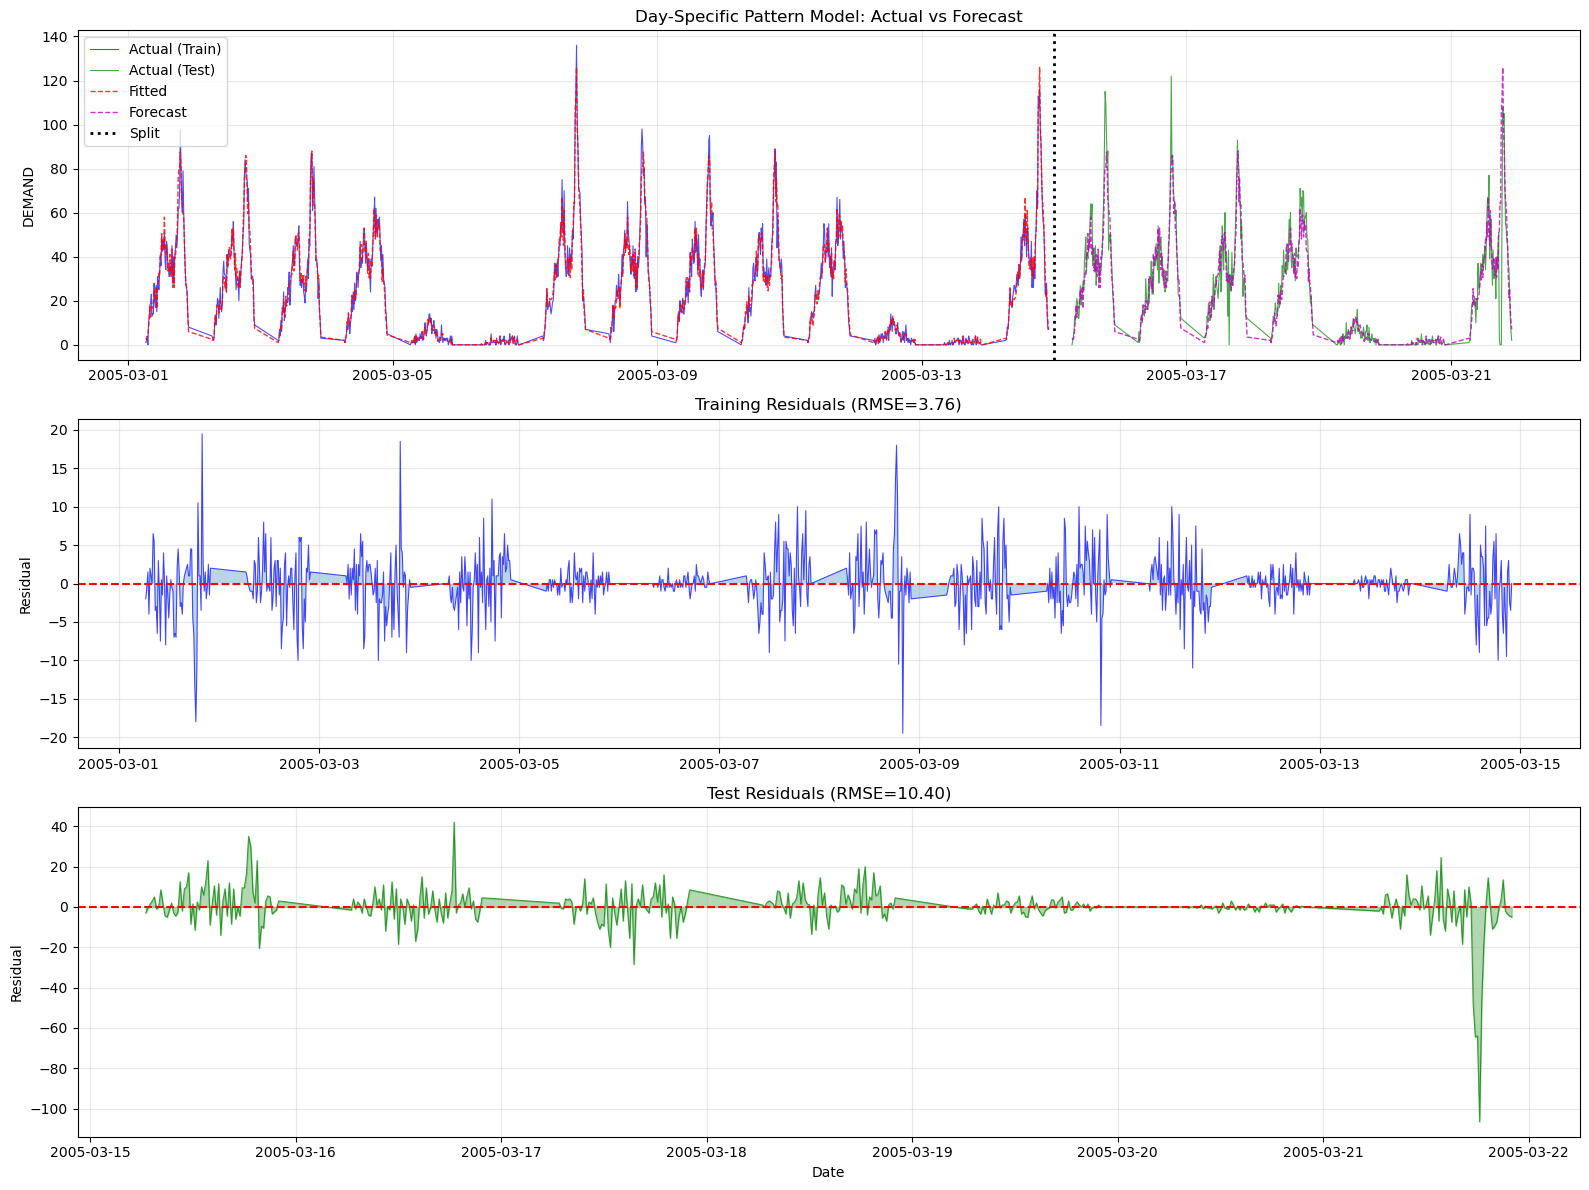

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Main plot: actual vs predictions
ax1 = axes[0]
ax1.plot(train_data.index, train_data['DEMAND'], 'b-', label='Actual (Train)', alpha=0.7, linewidth=0.8)
ax1.plot(test_data.index, test_data['DEMAND'], 'g-', label='Actual (Test)', alpha=0.7, linewidth=0.8)
ax1.plot(train_data.index, fitted_values_train, 'r--', label='Fitted', alpha=0.8, linewidth=1)
ax1.plot(test_data.index, forecast_series, 'm--', label='Forecast', alpha=0.8, linewidth=1)
ax1.axvline(x=pd.Timestamp('2005-03-15'), color='black', linestyle=':', linewidth=2, label='Split')
ax1.set_title('Day-Specific Pattern Model: Actual vs Forecast')
ax1.set_ylabel('DEMAND')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Training residuals
ax2 = axes[1]
ax2.plot(train_data.index, train_residuals, 'b-', alpha=0.7, linewidth=0.8)
ax2.axhline(y=0, color='red', linestyle='--')
ax2.fill_between(train_data.index, train_residuals, 0, alpha=0.3)
ax2.set_title(f'Training Residuals (RMSE={train_metrics["RMSE"]:.2f})')
ax2.set_ylabel('Residual')
ax2.grid(True, alpha=0.3)

# Test residuals
ax3 = axes[2]
ax3.plot(test_data.index, test_residuals, 'g-', alpha=0.7, linewidth=0.8)
ax3.axhline(y=0, color='red', linestyle='--')
ax3.fill_between(test_data.index, test_residuals, 0, alpha=0.3, color='green')
ax3.set_title(f'Test Residuals (RMSE={test_metrics["RMSE"]:.2f})')
ax3.set_xlabel('Date')
ax3.set_ylabel('Residual')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()